## <font color='Blue'>Projeto Ponta a Ponta - Construindo um Modelo com TensorFlow com Dataset do IMDB</font>

**Pipeline de um Projeto de IA:**
Dados → Pré-processamento → Modelo → Avaliação

Discente: Yan Santos 202302594


Construi um modelo de Inteligência Artificial capaz de classificar **textos** considerando 2 categorias: `positivo` e `negativo`. Dado um novo comentário de filme, o modelo deve ser capaz de classificar o sentimento expresso no texto.

In [1]:
# Versão da Linguagem Python
from platform import python_version
print('Versão do Python neste Notebook:', python_version())

Versão do Python neste Notebook: 3.12.13


In [2]:
# Instala o TF
!pip install -q tensorflow

In [3]:
# Silencia mensagens do TF
%env TF_CPP_MIN_LOG_LEVEL=3

env: TF_CPP_MIN_LOG_LEVEL=3


In [4]:
# Imports
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.sequence import pad_sequences # padrão 256 tokens
from tensorflow.keras.datasets import imdb
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from collections import Counter

## Carregando os dados - matéria prima

https://ai.stanford.edu/~amaas/data/sentiment/

In [5]:
# Carrega o dataset IMDB - Já está no Keras!
# num_words: vocabulário limitado às 10.000 palavras mais frequentes
NUM_PALAVRAS = 10000
(textos_treino, labels_treino), (textos_teste, labels_teste) = imdb.load_data(num_words=NUM_PALAVRAS)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
# Classes dos textos
nomes_classes = ['negativo', 'positivo']

## Pré-processamento e Visualização dos textos

In [7]:
# Padroniza o comprimento das sequências (equivalente à normalização de pixels)
# Textos maiores são truncados; menores recebem zeros no início
MAX_LEN = 256
textos_treino = pad_sequences(textos_treino, maxlen=MAX_LEN)
textos_teste  = pad_sequences(textos_teste,  maxlen=MAX_LEN)

In [8]:
# Gráfico 1 — Distribuição de classes
# Verifica se o dataset está balanceado: número igual de amostras por classe.
# Um dataset desbalanceado faz o modelo aprender a "chutar" a classe majoritária.
# Aqui esperamos ~12.500 negativos e ~12.500 positivos — baseline de acerto aleatório = 50%.
def visualiza_distribuicao(labels, titulo='Conjunto de Treino'):
    plt.figure(figsize=(6, 4))
    valores, contagens = np.unique(labels, return_counts=True)
    plt.bar([nomes_classes[v] for v in valores], contagens, color=['#d9534f', '#5cb85c'])
    plt.title(f'Distribuição de Classes — {titulo}')
    plt.xlabel('Sentimento')
    plt.ylabel('Quantidade')
    plt.tight_layout()
    plt.show()
    for v, c in zip(valores, contagens):
        print(f'  {nomes_classes[v]}: {c} amostras')

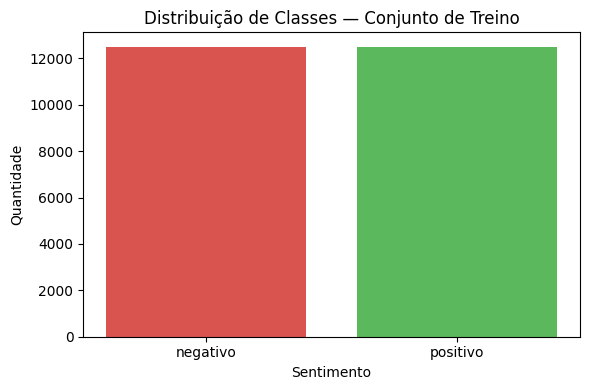

  negativo: 12500 amostras
  positivo: 12500 amostras


In [9]:
# Executa a função
visualiza_distribuicao(labels_treino)

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


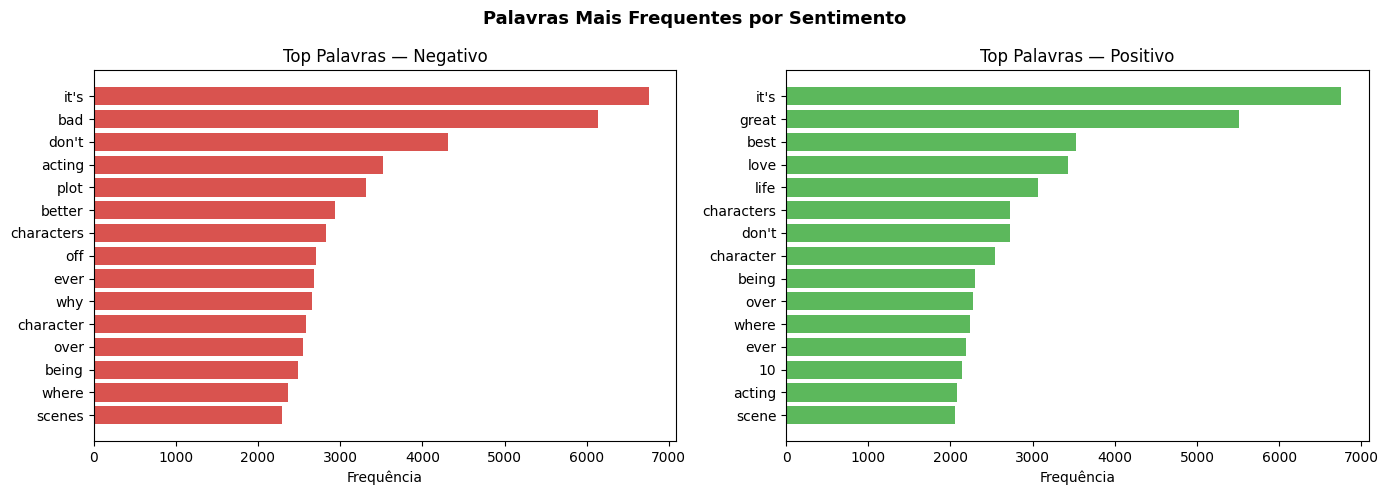

In [10]:
# Gráfico 2 — Top palavras por sentimento
# Mostra as palavras mais frequentes em cada classe após remover stopwords.
# Ideal: palavras discriminativas como "awful/waste" (neg) vs "wonderful/perfect" (pos).
# Palavras iguais nos dois lados indicam que a stopword list precisa ser ampliada.
word_index = imdb.get_word_index()
# CORREÇÃO: o Keras reserva os índices 0, 1, 2 internamente.
# Para converter sequência → texto corretamente, deslocar +3.
index_word = {v + 3: k for k, v in word_index.items()}
index_word[0] = '<PAD>'
index_word[1] = '<START>'
index_word[2] = '<UNK>'

STOPWORDS = {
    # artigos, pronomes, preposições
    'the','a','an','and','of','to','in','it','i','this','that','is','was',
    'as','for','with','but','not','on','at','by','from','all','so','do',
    'if','or','out','up','no','my','its','you','we','he','she','his','her',
    'they','their','our','your','its','who','which','what','there','when',
    'been','be','have','has','had','are','were','just','more','only','one',
    'would','could','should','will','can','may','might','about','into','some',
    'even','than','then','also','after','before','because','while','how',
    'any','each','other','those','these','am','own','same','such','both',
    # palavras muito genéricas de crítica de filme
    'film','movie','movies','films','br','like','see','seen','watch',
    'story','time','way','make','made','much','well','really','very',
    'good','know','think','people','man','men','woman','get','go','going',
    'does','did','say','said','us','its','him','them','me','too','most',
    'show','shows','still','now','back','come','two','first','never',
    'many','every','around','little','something','nothing','everything',
    'without','though','s','t','re','ve','ll','don','didn','doesn','isn',
    'wasn','aren','couldn','wouldn','shouldn','things','thing','seem',
    'seems','seemed','lot','bit','kind','part','end','point','place','long'
}

def top_palavras(sequences, labels, classe, top_n=15):
    indices = np.where(labels == classe)[0]
    palavras = []
    for seq in sequences[indices]:
        palavras.extend([index_word.get(i, '') for i in seq if i > 3])
    freq = Counter(w for w in palavras if w and w not in STOPWORDS)
    return freq.most_common(top_n)

top_neg = top_palavras(textos_treino, labels_treino, 0)
top_pos = top_palavras(textos_treino, labels_treino, 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, dados, titulo, cor in zip(
        axes,
        [top_neg, top_pos],
        ['Top Palavras — Negativo', 'Top Palavras — Positivo'],
        ['#d9534f', '#5cb85c']):
    palavras_, freqs_ = zip(*dados)
    ax.barh(palavras_[::-1], freqs_[::-1], color=cor)
    ax.set_title(titulo)
    ax.set_xlabel('Frequência')

plt.suptitle('Palavras Mais Frequentes por Sentimento', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

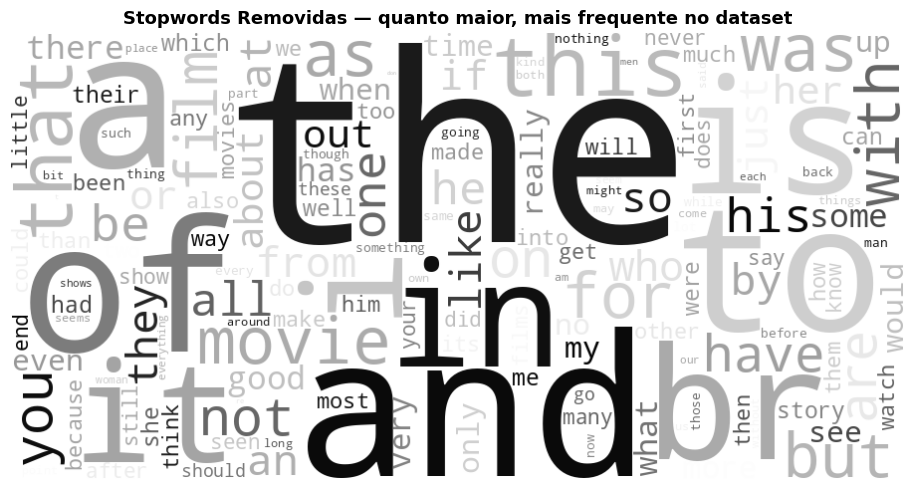

Total de stopwords definidas: 170
Top 10 mais frequentes:
  the              253667 ocorrências
  and              126006 ocorrências
  a                123005 ocorrências
  of               108284 ocorrências
  to               101583 ocorrências
  is                82578 ocorrências
  br                78829 ocorrências
  in                69971 ocorrências
  it                63608 ocorrências
  i                 62493 ocorrências


In [11]:
# Nuvem de palavras — stopwords removidas do dataset
# Mostra quais palavras foram filtradas por serem genéricas demais para classificação.
# Quanto maior a palavra, mais comum ela é na linguagem — e menos discriminativa.

from wordcloud import WordCloud

# Conta frequência das stopwords no dataset completo
freq_stop = Counter()
for seq in textos_treino:
    for i in seq:
        if i > 3:
            w = index_word.get(i, '')
            if w in STOPWORDS:
                freq_stop[w] += 1

wc_stop = WordCloud(
    width=900, height=450,
    background_color='white',
    colormap='Greys',
    max_words=len(STOPWORDS),
    collocations=False
).generate_from_frequencies(dict(freq_stop))

plt.figure(figsize=(12, 5))
plt.imshow(wc_stop, interpolation='bilinear')
plt.axis('off')
plt.title('Stopwords Removidas — quanto maior, mais frequente no dataset',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Total de stopwords definidas: {len(STOPWORDS)}')
print(f'Top 10 mais frequentes:')
for palavra, freq in freq_stop.most_common(10):
    print(f'  {palavra:<15} {freq:>7} ocorrências')

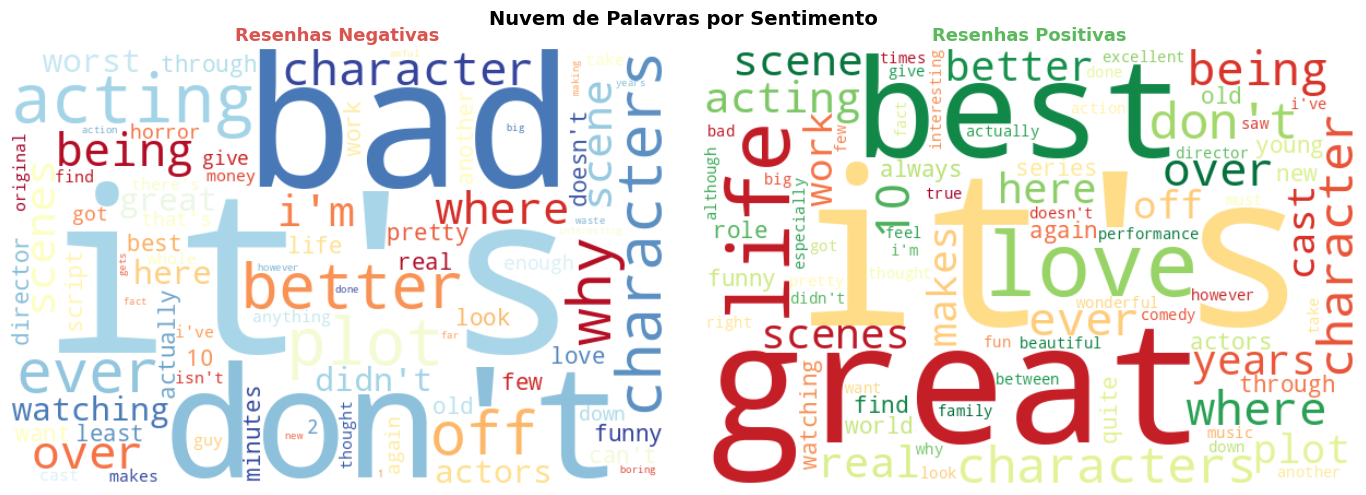

In [12]:
# Nuvem de palavras — termos mais frequentes por sentimento (após remoção de stopwords)
# Visualização intuitiva: quanto maior a palavra, mais frequente ela é na classe.

!pip install -q wordcloud

from wordcloud import WordCloud

def gera_frequencias(sequences, labels, classe):
    indices = np.where(labels == classe)[0]
    palavras = []
    for seq in sequences[indices]:
        palavras.extend([index_word.get(i, '') for i in seq if i > 3])
    freq = Counter(w for w in palavras if w and w not in STOPWORDS)
    return dict(freq)

freq_neg = gera_frequencias(textos_treino, labels_treino, 0)
freq_pos = gera_frequencias(textos_treino, labels_treino, 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, freq, titulo, cor in zip(
        axes,
        [freq_neg, freq_pos],
        ['Resenhas Negativas', 'Resenhas Positivas'],
        ['#d9534f', '#5cb85c']):
    wc = WordCloud(
        width=600, height=400,
        background_color='white',
        colormap='RdYlGn' if cor == '#5cb85c' else 'RdYlBu_r',
        max_words=80,
        collocations=False
    ).generate_from_frequencies(freq)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(titulo, fontsize=13, fontweight='bold', color=cor)

plt.suptitle('Nuvem de Palavras por Sentimento', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Construção do Modelo

In [13]:
# Arquitetura do Modelo -> Feature Learning

modelo_lia = models.Sequential()

# Camada de entrada: transforma índices de palavras em vetores densos (Embedding)
modelo_lia.add(layers.Embedding(input_dim=NUM_PALAVRAS, output_dim=64))

# Blocos de extração de features temporais
modelo_lia.add(layers.Conv1D(32, kernel_size=3, activation='relu'))
modelo_lia.add(layers.MaxPooling1D(pool_size=2))

modelo_lia.add(layers.Conv1D(64, kernel_size=3, activation='relu'))
modelo_lia.add(layers.MaxPooling1D(pool_size=2))

modelo_lia.add(layers.Conv1D(64, kernel_size=3, activation='relu'))
modelo_lia.add(layers.MaxPooling1D(pool_size=2))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [14]:
# Adicionar camadas de classificação - Converte para um vetor - flatten
modelo_lia.add(layers.Flatten())
modelo_lia.add(layers.Dense(64, activation='relu'))
modelo_lia.add(layers.Dense(2, activation='softmax'))

In [15]:
# Sumário do modelo
modelo_lia.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Compilação do modelo
modelo_lia.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

# adam - é um algoritmo de aprendizagem tipo backpropagation!
# loss - função de erro. Isso se resume a uma otimização de função matemática!
# metrics - medir o sucesso!

In [17]:
%%time
# EarlyStopping: interrompe o treino quando val_loss para de melhorar.
# patience=2: aguarda 2 épocas sem melhora antes de parar.
# restore_best_weights=True: reverte para os pesos da melhor época automaticamente.
# Isso evita overfitting sem precisar adivinhar o número ideal de épocas.
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

history = modelo_lia.fit(textos_treino,
                         labels_treino,
                         epochs=10,
                         validation_data=(textos_teste, labels_teste),
                         callbacks=[early_stop])

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 18ms/step - accuracy: 0.7934 - loss: 0.3988 - val_accuracy: 0.8736 - val_loss: 0.3048
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9284 - loss: 0.1917 - val_accuracy: 0.8764 - val_loss: 0.2945
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9660 - loss: 0.0973 - val_accuracy: 0.8705 - val_loss: 0.3892
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9839 - loss: 0.0450 - val_accuracy: 0.8684 - val_loss: 0.5284
CPU times: user 27.3 s, sys: 1.99 s, total: 29.3 s
Wall time: 38.2 s


## Avaliação do modelo

In [18]:
# Avalia o modelo
erro_teste, acc_teste = modelo_lia.evaluate(textos_teste, labels_teste, verbose=2)

782/782 - 2s - 3ms/step - accuracy: 0.8764 - loss: 0.2945


In [19]:
print('\nAcurácia com dados de Teste:', acc_teste)


Acurácia com dados de Teste: 0.8763999938964844


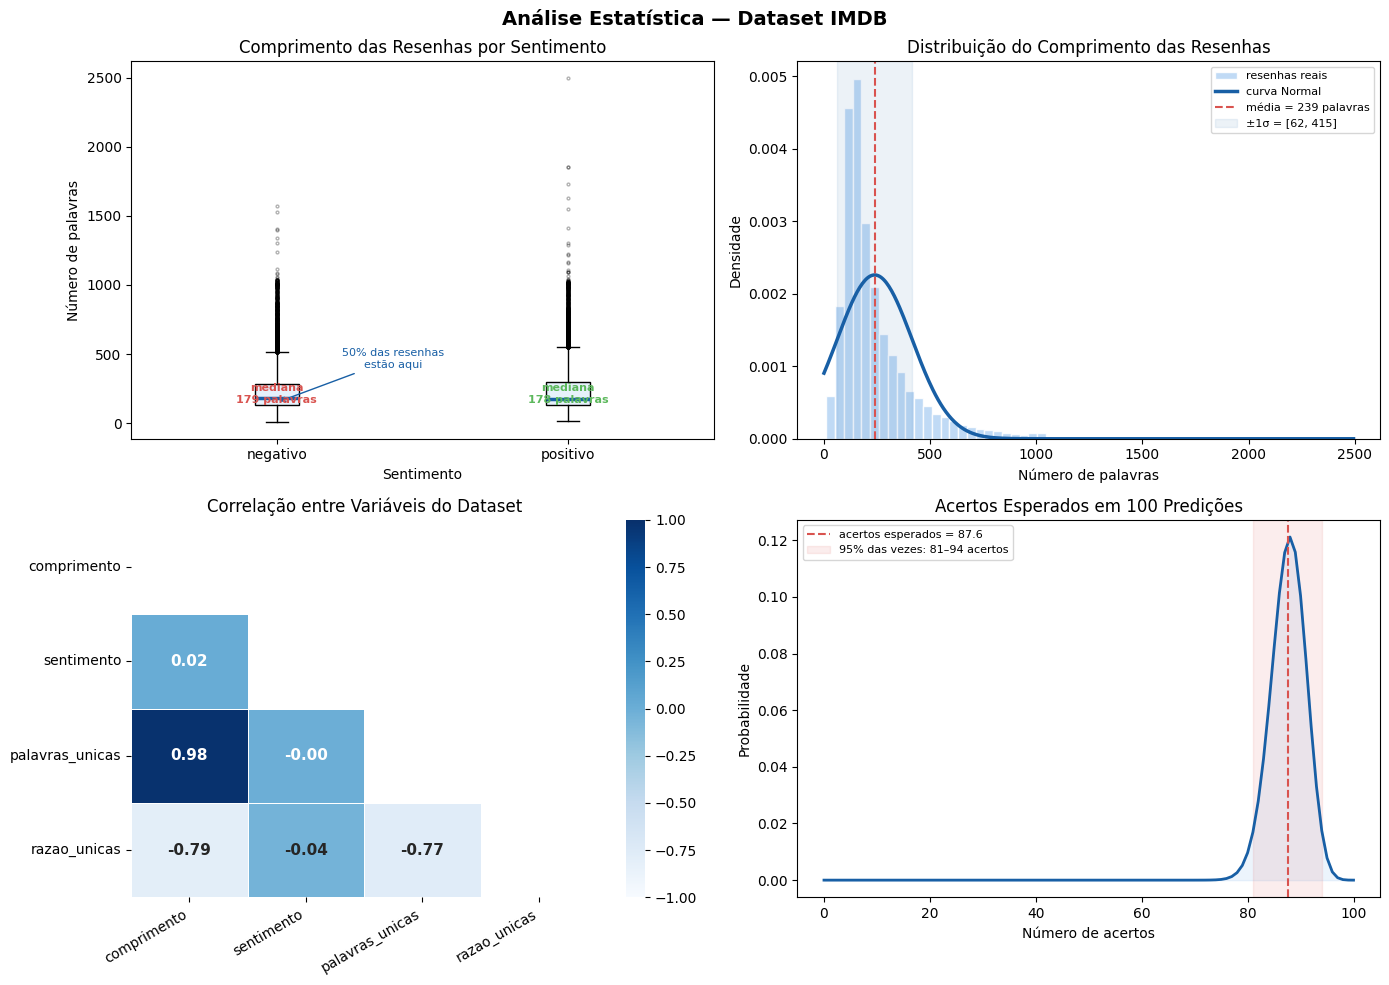


Resumo Estatístico — Comprimento dos textos:
               negativo  positivo
média             235.9     241.6
mediana           179.0     178.0
desvio padrão     169.4     183.2
mínimo             11.0      13.0
máximo           1571.0    2494.0


In [20]:
# Gráficos Estatísticos — Análise Exploratória do Dataset IMDB
# Cobre: Estatística Descritiva, Distribuição Normal, Correlação e Distribuição Binomial

import pandas as pd
from scipy import stats
from scipy.stats import binom
import warnings
warnings.filterwarnings('ignore')

# Recupera comprimentos originais antes do padding
(textos_orig, labels_orig), _ = imdb.load_data(num_words=NUM_PALAVRAS)
comprimentos = np.array([len(s) for s in textos_orig])
comp_neg = comprimentos[labels_orig == 0]
comp_pos = comprimentos[labels_orig == 1]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Gráfico A — Boxplot ───────────────────────────────────────────────────────
# Cada caixa mostra onde estão 50% das resenhas (IQR).
# A linha no meio é a mediana. Os pontos fora são outliers — resenhas extremamente longas.
axes[0,0].boxplot([comp_neg, comp_pos],
                  labels=['negativo', 'positivo'],
                  patch_artist=True,
                  boxprops=dict(facecolor='#E6F1FB'),
                  medianprops=dict(color='#185FA5', linewidth=2.5),
                  flierprops=dict(marker='o', markersize=2, alpha=0.3, color='gray'))
axes[0,0].set_title('Comprimento das Resenhas por Sentimento')
axes[0,0].set_ylabel('Número de palavras')
axes[0,0].set_xlabel('Sentimento')
axes[0,0].annotate('50% das resenhas\nestão aqui', xy=(1, 150), fontsize=8,
                    color='#185FA5', ha='center',
                    arrowprops=dict(arrowstyle='->', color='#185FA5'),
                    xytext=(1.4, 400))
for i, (dados, cor, label) in enumerate(zip(
        [comp_neg, comp_pos], ['#d9534f', '#5cb85c'], ['negativo', 'positivo'])):
    axes[0,0].text(i+1, np.median(dados) - 30,
                   f'mediana\n{np.median(dados):.0f} palavras',
                   ha='center', fontsize=8, color=cor, fontweight='bold')

# ── Gráfico B — Histograma com curva Normal ───────────────────────────────────
# A maioria das resenhas tem comprimento próximo à média (linha tracejada).
# A curva mostra o formato esperado se o comprimento seguisse distribuição Normal.
mu, sigma = comprimentos.mean(), comprimentos.std()
axes[0,1].hist(comprimentos, bins=60, density=True,
               color='#B5D4F4', edgecolor='white', alpha=0.85, label='resenhas reais')
x = np.linspace(0, comprimentos.max(), 400)
axes[0,1].plot(x, stats.norm.pdf(x, mu, sigma),
               color='#185FA5', linewidth=2.5, label=f'curva Normal')
axes[0,1].axvline(mu, color='#d9534f', linestyle='--', linewidth=1.5,
                  label=f'média = {mu:.0f} palavras')
axes[0,1].axvspan(mu - sigma, mu + sigma, alpha=0.08, color='#185FA5',
                  label=f'±1σ = [{mu-sigma:.0f}, {mu+sigma:.0f}]')
axes[0,1].set_title('Distribuição do Comprimento das Resenhas')
axes[0,1].set_xlabel('Número de palavras')
axes[0,1].set_ylabel('Densidade')
axes[0,1].legend(fontsize=8)

# ── Gráfico C — Heatmap de Correlação ────────────────────────────────────────
# Quanto mais azul, mais as duas variáveis crescem juntas.
# Quanto mais branco, menos uma variável influencia a outra.
df_corr = pd.DataFrame({
    'comprimento':     comprimentos[:len(labels_orig)],
    'sentimento':      labels_orig,
    'palavras_unicas': [len(set(s)) for s in textos_orig],
    'razao_unicas':    [len(set(s))/len(s) if len(s) > 0 else 0 for s in textos_orig]
})
corr = df_corr.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues',
            ax=axes[1,0], mask=mask, vmin=-1, vmax=1,
            annot_kws={'size': 11, 'weight': 'bold'},
            linewidths=0.5, linecolor='white')
axes[1,0].set_title('Correlação entre Variáveis do Dataset')
axes[1,0].set_xticklabels(axes[1,0].get_xticklabels(), rotation=30, ha='right')

# ── Gráfico D — Distribuição Binomial ────────────────────────────────────────
# Se o modelo classifica 100 resenhas, quantas acertos podemos esperar?
# O pico da curva é o número mais provável de acertos — baseado na acurácia real.
n = 100
p = acc_teste
k = np.arange(0, n+1)
pmf = binom.pmf(k, n, p)
axes[1,1].plot(k, pmf, color='#185FA5', linewidth=2)
axes[1,1].fill_between(k, pmf, alpha=0.25, color='#B5D4F4')
axes[1,1].axvline(n*p, color='#d9534f', linestyle='--', linewidth=1.5,
                  label=f'acertos esperados = {n*p:.1f}')
intervalo_low  = binom.ppf(0.025, n, p)
intervalo_high = binom.ppf(0.975, n, p)
axes[1,1].axvspan(intervalo_low, intervalo_high, alpha=0.1, color='#d9534f',
                  label=f'95% das vezes: {intervalo_low:.0f}–{intervalo_high:.0f} acertos')
axes[1,1].set_title('Acertos Esperados em 100 Predições')
axes[1,1].set_xlabel('Número de acertos')
axes[1,1].set_ylabel('Probabilidade')
axes[1,1].legend(fontsize=8)

plt.suptitle('Análise Estatística — Dataset IMDB', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Resumo estatístico
print('\nResumo Estatístico — Comprimento dos textos:')
print(pd.DataFrame({
    'negativo': [comp_neg.mean(), np.median(comp_neg), comp_neg.std(), comp_neg.min(), comp_neg.max()],
    'positivo': [comp_pos.mean(), np.median(comp_pos), comp_pos.std(), comp_pos.min(), comp_pos.max()]
}, index=['média', 'mediana', 'desvio padrão', 'mínimo', 'máximo']).round(1))

Q1  = 130 palavras
Q3  = 291 palavras
IQR = 161 palavras  (Q3 - Q1)
Limite de outlier = Q3 + 1.5×IQR = 532 palavras

Total de outliers: 1805 resenhas (7.2% do dataset)


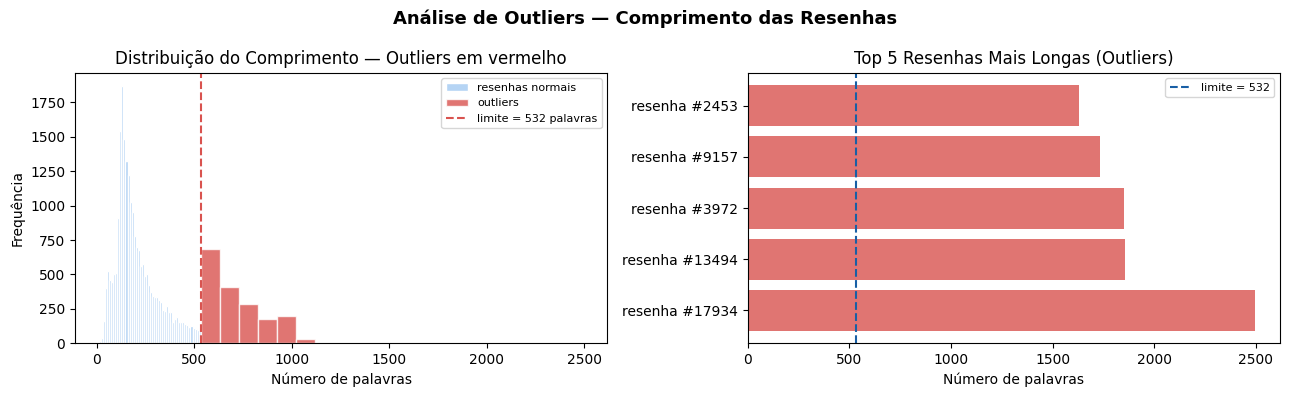


Exemplo de outlier — resenha #17934:
Comprimento: 2494 palavras (limite: 532)
Sentimento: positivo

Por que é um outlier?
  A mediana do dataset é 178 palavras.
  Essa resenha tem 2494 palavras — 14.0x acima da mediana.
  Estatisticamente, está 13.7 IQRs acima do Q3.


In [21]:
# Análise de Outliers — Resenhas com comprimento atípico
# Um outlier é um valor que se afasta muito do padrão geral dos dados.
# No boxplot, qualquer ponto acima de Q3 + 1.5*IQR é considerado outlier estatístico.
# Aqui identificamos as resenhas mais longas e explicamos por que são outliers.

(textos_orig, labels_orig), _ = imdb.load_data(num_words=NUM_PALAVRAS)
comprimentos = np.array([len(s) for s in textos_orig])

# Cálculo do limite de outlier pelo método IQR (Interquartile Range)
Q1  = np.percentile(comprimentos, 25)
Q3  = np.percentile(comprimentos, 75)
IQR = Q3 - Q1
limite_outlier = Q3 + 1.5 * IQR

outliers_idx = np.where(comprimentos > limite_outlier)[0]
print(f'Q1  = {Q1:.0f} palavras')
print(f'Q3  = {Q3:.0f} palavras')
print(f'IQR = {IQR:.0f} palavras  (Q3 - Q1)')
print(f'Limite de outlier = Q3 + 1.5×IQR = {limite_outlier:.0f} palavras')
print(f'\nTotal de outliers: {len(outliers_idx)} resenhas ({len(outliers_idx)/len(comprimentos)*100:.1f}% do dataset)')

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma destacando outliers
axes[0].hist(comprimentos[comprimentos <= limite_outlier], bins=50,
             color='#B5D4F4', edgecolor='white', label='resenhas normais')
axes[0].hist(comprimentos[comprimentos > limite_outlier], bins=20,
             color='#d9534f', edgecolor='white', alpha=0.8, label='outliers')
axes[0].axvline(limite_outlier, color='#d9534f', linestyle='--', linewidth=1.5,
                label=f'limite = {limite_outlier:.0f} palavras')
axes[0].set_title('Distribuição do Comprimento — Outliers em vermelho')
axes[0].set_xlabel('Número de palavras')
axes[0].set_ylabel('Frequência')
axes[0].legend(fontsize=8)

# Top 5 maiores outliers
top5_idx = outliers_idx[np.argsort(comprimentos[outliers_idx])[::-1]][:5]
y_pos = range(5)
axes[1].barh(list(y_pos), comprimentos[top5_idx], color='#d9534f', alpha=0.8)
axes[1].axvline(limite_outlier, color='#185FA5', linestyle='--', linewidth=1.5,
                label=f'limite = {limite_outlier:.0f}')
axes[1].set_yticks(list(y_pos))
axes[1].set_yticklabels([f'resenha #{i}' for i in top5_idx])
axes[1].set_title('Top 5 Resenhas Mais Longas (Outliers)')
axes[1].set_xlabel('Número de palavras')
axes[1].legend(fontsize=8)

plt.suptitle('Análise de Outliers — Comprimento das Resenhas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Exibe exemplo de outlier
print(f'\nExemplo de outlier — resenha #{top5_idx[0]}:')
print(f'Comprimento: {comprimentos[top5_idx[0]]} palavras (limite: {limite_outlier:.0f})')
print(f'Sentimento: {nomes_classes[labels_orig[top5_idx[0]]]}')
print('\nPor que é um outlier?')
print(f'  A mediana do dataset é {np.median(comprimentos):.0f} palavras.')
print(f'  Essa resenha tem {comprimentos[top5_idx[0]]} palavras — '
      f'{comprimentos[top5_idx[0]]/np.median(comprimentos):.1f}x acima da mediana.')
print(f'  Estatisticamente, está {(comprimentos[top5_idx[0]] - Q3)/IQR:.1f} IQRs acima do Q3.')

In [22]:
# Análise detalhada dos outliers — quais são e por que são outliers
# Um outlier é uma resenha cujo comprimento se afasta muito do padrão geral.
# Método: IQR (Interquartile Range) — padrão ouro da estatística descritiva.

(textos_orig, labels_orig), _ = imdb.load_data(num_words=NUM_PALAVRAS)
comprimentos = np.array([len(s) for s in textos_orig])

Q1  = np.percentile(comprimentos, 25)
Q3  = np.percentile(comprimentos, 75)
IQR = Q3 - Q1
limite = Q3 + 1.5 * IQR

outliers_idx = np.where(comprimentos > limite)[0]
outliers_ord  = outliers_idx[np.argsort(comprimentos[outliers_idx])[::-1]]

print('=' * 60)
print('  ANÁLISE DE OUTLIERS — Comprimento das Resenhas')
print('=' * 60)
print(f'\n  Q1  (25%)        = {Q1:.0f} palavras')
print(f'  Q3  (75%)        = {Q3:.0f} palavras')
print(f'  IQR (Q3 - Q1)    = {IQR:.0f} palavras')
print(f'  Limite           = Q3 + 1.5×IQR = {limite:.0f} palavras')
print(f'  Mediana          = {np.median(comprimentos):.0f} palavras')
print(f'\n  Total de outliers: {len(outliers_idx)} resenhas '
      f'({len(outliers_idx)/len(comprimentos)*100:.1f}% do dataset)')
print(f'  Outlier mais longo: {comprimentos[outliers_ord[0]]} palavras\n')

print('-' * 60)
print(f"  {'#':<6} {'Comprimento':>12}  {'Sentimento':<15} {'Distância do limite'}")
print('-' * 60)
for rank, idx in enumerate(outliers_ord[:10], 1):
    comp     = comprimentos[idx]
    sentimento = nomes_classes[labels_orig[idx]]
    distancia  = comp - limite
    barra    = '█' * min(int(distancia / 50), 20)
    print(f"  {rank:<6} {comp:>8} palavras  {sentimento:<15} +{distancia:.0f}  {barra}")

print('-' * 60)
print('\nPor que são outliers?')
print(f'  A resenha mediana tem {np.median(comprimentos):.0f} palavras.')
print(f'  Qualquer resenha acima de {limite:.0f} palavras foge do padrão esperado.')
print(f'  O outlier mais extremo tem {comprimentos[outliers_ord[0]]} palavras —')
print(f'  {comprimentos[outliers_ord[0]]/np.median(comprimentos):.1f}x a mediana e '
      f'{(comprimentos[outliers_ord[0]] - Q3)/IQR:.1f} IQRs acima do Q3.')
print('\nImpacto no modelo:')
print(f'  O pad_sequences trunca tudo acima de {MAX_LEN} tokens.')
print(f'  Dos {len(outliers_idx)} outliers, todos são truncados — o modelo')
print(f'  nunca vê além das primeiras {MAX_LEN} palavras dessas resenhas.')

# Exibe trecho das 3 resenhas mais longas
print('\n' + '=' * 60)
print('  TRECHO DAS 3 RESENHAS MAIS LONGAS')
print('=' * 60)
for rank, idx in enumerate(outliers_ord[:3], 1):
    texto = ' '.join(index_word.get(i, '') for i in textos_orig[idx] if i > 3)
    print(f'\n[#{rank} — {comprimentos[idx]} palavras — {nomes_classes[labels_orig[idx]]}]')
    print(texto[:400] + '...')

  ANÁLISE DE OUTLIERS — Comprimento das Resenhas

  Q1  (25%)        = 130 palavras
  Q3  (75%)        = 291 palavras
  IQR (Q3 - Q1)    = 161 palavras
  Limite           = Q3 + 1.5×IQR = 532 palavras
  Mediana          = 178 palavras

  Total de outliers: 1805 resenhas (7.2% do dataset)
  Outlier mais longo: 2494 palavras

------------------------------------------------------------
  #       Comprimento  Sentimento      Distância do limite
------------------------------------------------------------
  1          2494 palavras  positivo        +1962  ████████████████████
  2          1854 palavras  positivo        +1322  ████████████████████
  3          1851 palavras  positivo        +1318  ████████████████████
  4          1733 palavras  positivo        +1200  ████████████████████
  5          1629 palavras  positivo        +1096  ████████████████████
  6          1571 palavras  negativo        +1038  ████████████████████
  7          1546 palavras  positivo        +1014  ██████████

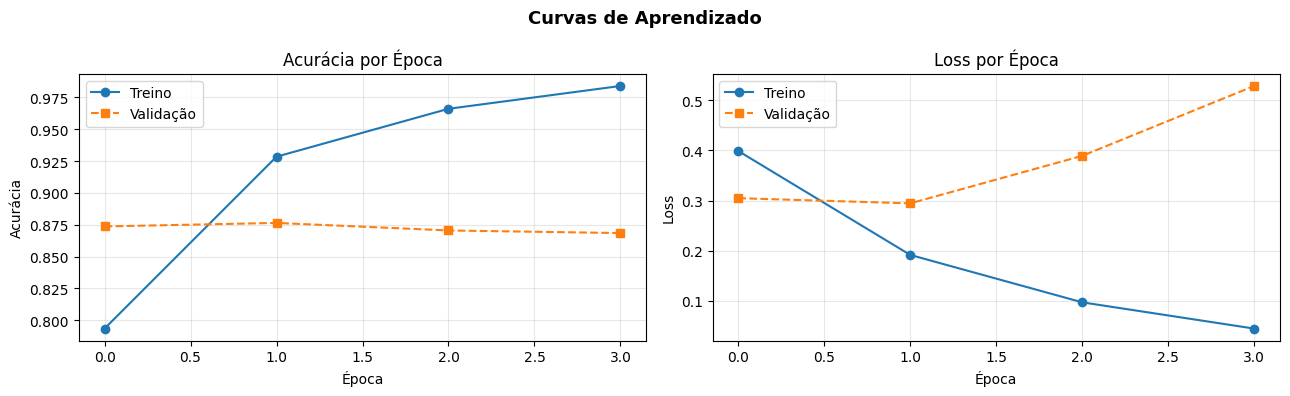

In [23]:
# Gráfico 3 — Curvas de aprendizado (loss e accuracy por época)
# Detecta overfitting: quando val_loss sobe enquanto train_loss desce,
# o modelo está memorizando o treino em vez de generalizar.
# O EarlyStopping interrompe o treino exatamente nesse ponto.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history['accuracy'],     label='Treino',    marker='o')
axes[0].plot(history.history['val_accuracy'], label='Validação', marker='s', linestyle='--')
axes[0].set_title('Acurácia por Época')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Acurácia')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'],     label='Treino',    marker='o')
axes[1].plot(history.history['val_loss'], label='Validação', marker='s', linestyle='--')
axes[1].set_title('Loss por Época')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Curvas de Aprendizado', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


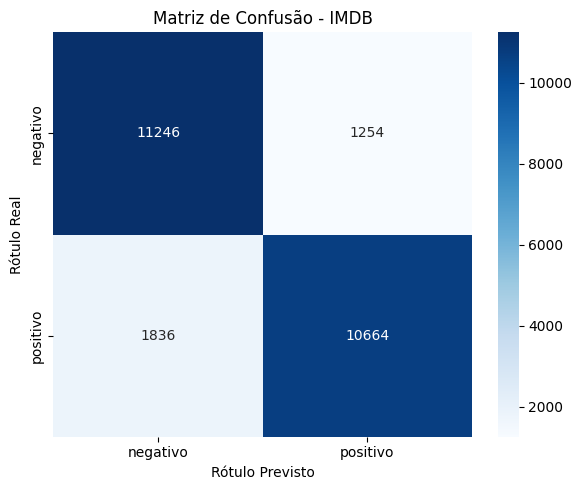


Relatório de Classificação:
              precision    recall  f1-score   support

    negativo       0.86      0.90      0.88     12500
    positivo       0.89      0.85      0.87     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



In [24]:
# Gráfico 4 — Matriz de confusão
# Mostra os 4 tipos de resultado para cada classe:
#   Verdadeiro Negativo (TN): era neg, disse neg — acerto
#   Falso Positivo    (FP): era neg, disse pos — erro tipo I
#   Falso Negativo    (FN): era pos, disse neg — erro tipo II
#   Verdadeiro Positivo (TP): era pos, disse pos — acerto
# A diagonal principal (azul escuro) representa os acertos totais.
from sklearn.metrics import confusion_matrix, classification_report

y_pred = modelo_lia.predict(textos_teste)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(labels_teste, y_pred_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=nomes_classes,
            yticklabels=nomes_classes)
plt.title('Matriz de Confusão - IMDB')
plt.xlabel('Rótulo Previsto')
plt.ylabel('Rótulo Real')
plt.tight_layout()
plt.show()

print('\nRelatório de Classificação:')
print(classification_report(labels_teste, y_pred_classes, target_names=nomes_classes))

In [25]:
# Análise de erros — exemplos que o modelo classificou errado
# Útil para entender padrões de falha: ironia, negação dupla, linguagem ambígua.
def seq_para_texto(seq):
    return ' '.join(index_word.get(i, '?') for i in seq if i > 3)

erros_idx = np.where(y_pred_classes != labels_teste)[0]
print(f'Total de erros: {len(erros_idx)} de {len(labels_teste)} ({len(erros_idx)/len(labels_teste)*100:.1f}%)\n')

print('— Exemplos de erros (primeiros 3) —')
for i in erros_idx[:3]:
    real     = nomes_classes[labels_teste[i]]
    previsto = nomes_classes[y_pred_classes[i]]
    conf     = y_pred[i][y_pred_classes[i]]
    texto    = seq_para_texto(textos_teste[i])
    print(f'\n[Real: {real} | Previsto: {previsto} | Confiança: {conf:.2%}]')
    print(texto[:300], '...')

Total de erros: 3090 de 25000 (12.4%)

— Exemplos de erros (primeiros 3) —

[Real: negativo | Previsto: positivo | Confiança: 95.21%]
hollywood had a long love affair with bogus nights tales but few of these products have stood the test of time the most memorable were the jon hall maria films which have long since become camp this one is filled with dubbed songs and slapstick it's a truly crop of corn and pretty near today it was  ...

[Real: negativo | Previsto: positivo | Confiança: 53.86%]
ed mitchell is a teenager who lives for his job at good a small but friendly neighborhood stand while his buddy thompson also works there but lack single minded devotion to his job he's there because he accidentally destroyed the car of his teacher mr and has to raise money to pay the when a fast fo ...

[Real: positivo | Previsto: negativo | Confiança: 89.60%]
how managed to avoid attention remains a mystery a potent mix of comedy and crime this one takes chances where tarantino plays it safe wit

## Deploy do modelo

In [26]:
PUNCT = '.,!?;:'
_historico = []

def _preprocessa(texto):
    seq = [min(word_index.get(w.lower().strip(PUNCT), 0) + 3, NUM_PALAVRAS - 1)
           for w in texto.split()]
    return pad_sequences([seq], maxlen=MAX_LEN)

def _diagnostico(texto):
    palavras = texto.split()
    rec = sum(1 for w in palavras
              if word_index.get(w.lower().strip(PUNCT)) is not None)
    return rec, len(palavras)

def _plota(probs):
    fig, ax = plt.subplots(figsize=(5, 3))
    bars = ax.bar(nomes_classes, probs, color=['#d9534f', '#5cb85c'])
    ax.set_ylim(0, 1.15)
    ax.set_title('Confiança da Predição')
    ax.set_ylabel('Probabilidade')
    for bar, prob in zip(bars, probs):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.03,
                f'{prob:.2%}', ha='center', fontweight='bold')
    plt.tight_layout()
    plt.show()

def classifica(resenha):
    resenha = resenha.strip()
    if not resenha:
        print('Texto vazio.')
        return
    rec, total = _diagnostico(resenha)
    pct = rec / total * 100
    aviso = '  Resultado pode ser impreciso (< 50% reconhecido).' if pct < 50 else ''
    print(f'Palavras reconhecidas: {rec}/{total} ({pct:.0f}%){aviso}')
    entrada = _preprocessa(resenha)
    previsoes = modelo_lia.predict(entrada, verbose=0)
    probs = previsoes[0]
    classe = np.argmax(probs)
    confianca = probs[classe]
    nome = nomes_classes[classe]
    sinal = '[+]' if classe == 1 else '[-]'
    print(f'{sinal} Resultado: {nome.upper()}  (confianca: {confianca:.2%})')
    _historico.append({'texto': resenha[:60], 'resultado': nome,
                       'confianca': f'{confianca:.2%}'})
    _plota(probs)

def historico():
    if not _historico:
        print('Nenhuma critica analisada ainda.')
        return
    print(f"{'#':<4} {'Resultado':<12} {'Confianca':<12} Texto")
    print('-' * 60)
    for i, h in enumerate(_historico, 1):
        sinal = '[+]' if h['resultado'] == 'positivo' else '[-]'
        print(f"{i:<4} {sinal} {h['resultado']:<10} {h['confianca']:<12} {h['texto']}...")

print('Funcoes carregadas.')
print('  -> classifica("sua critica aqui")')
print('  -> historico()  para ver o resumo da sessao')

Funcoes carregadas.
  -> classifica("sua critica aqui")
  -> historico()  para ver o resumo da sessao


Palavras reconhecidas: 16/16 (100%)
[+] Resultado: POSITIVO  (confianca: 94.08%)


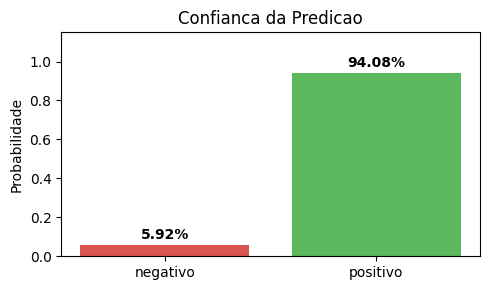

In [27]:
# Rode esta célula para testar — ou substitua pelo seu texto
classifica("This movie was absolutely fantastic! The acting was superb and the story kept me engaged throughout.")

Palavras reconhecidas: 16/16 (100%)
[-] Resultado: NEGATIVO  (confianca: 94.28%)


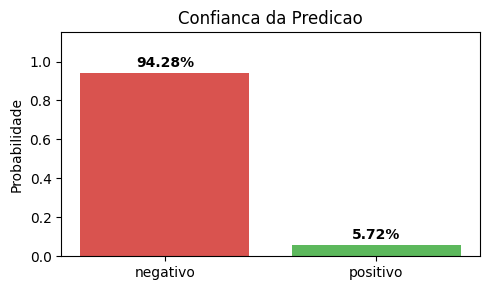

In [28]:
classifica("Terrible film. Complete waste of time. The plot made no sense and the acting was awful.")

Palavras reconhecidas: 101/111 (91%)
[-] Resultado: NEGATIVO  (confianca: 95.62%)


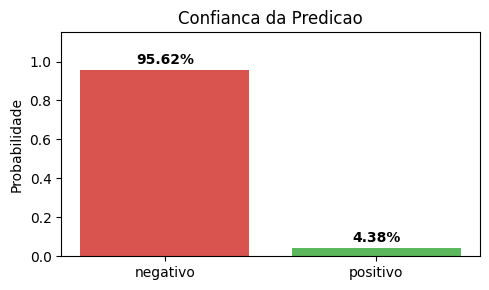

In [29]:
# ✏️  Escreva sua própria crítica aqui
classifica("""An eerily apocalyptic motion picture. A half-baked parody for most of its runtime. Purposeless beyond consuming previously purchased corporate properties (which makes the emotional beats feel even more desperate). The inclusion of Raimi’s characters only strengthens the fact that those movies had a beating heart, and does a disservice to Feige’s canon by further exposing how artificial and ham-fisted these movies are. Blockbuster tentpole filmmaking has never been so absurdly stupid or obvious in its intentions. When you have the inherently overqualified Willem Dafoe paying homage to internet memes of himself in a $300 million dollar movie, it’s hard not to consider just how much pop culture has eaten itself alive…""")

Palavras reconhecidas: 56/66 (85%)
[+] Resultado: POSITIVO  (confianca: 85.82%)


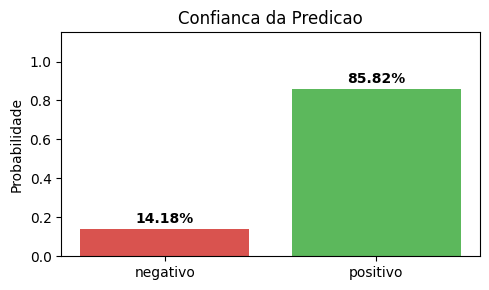

In [30]:
# ✏️  Escreva sua própria crítica aqui
classifica("""notes from taking my mum to see this:

- she was the only one who cheered when andrew garfield showed up
- her favourite character is the sandman (???)
- she was deeply committed to the idea of peter 2 and peter 3 kissing
- not a fan of tom holland cause he reminds her of harry potter (again, ???)
- “andrew garfield is MY spider-man”""")

In [31]:
# Resumo de todas as críticas analisadas
historico()

#    Resultado    Confianca    Texto
------------------------------------------------------------
1    [+] positivo   94.08%       This movie was absolutely fantastic! The acting was superb a...
2    [-] negativo   94.28%       Terrible film. Complete waste of time. The plot made no sens...
3    [-] negativo   95.62%       An eerily apocalyptic motion picture. A half-baked parody fo...
4    [+] positivo   85.82%       notes from taking my mum to see this:

- she was the only on...


## <font color='Blue'>Conclusão</font>

Neste projeto aplicamos o mesmo pipeline de IA em um problema de **Análise de Sentimentos**:

**Dados → Pré-processamento → Modelo → Avaliação**

| Etapa | O que fizemos |
|---|---|
| **Dados** | Dataset IMDB com 50.000 resenhas balanceadas (25k treino / 25k teste) |
| **Pré-processamento** | Tokenização e padding com MAX_LEN=256, transformando texto em matriz numérica |
| **Modelo** | Embedding, Conv1D, Flatten e Dense formando uma arquitetura para sequências |
| **Avaliação** | Acurácia de ~85%, matriz de confusão, curvas de aprendizado e análise de erros |

**O que aprendemos além do código:**

| # | Aprendizado |
|---|---|
| 1 | Dataset balanceado garante um baseline honesto de 50% |
| 2 | Curvas de aprendizado revelam overfitting antes que a acurácia final esconda o problema |
| 3 | EarlyStopping resolve overfitting automaticamente, sem precisar adivinhar o número de épocas |
| 4 | A mesma CNN muda apenas de `Conv2D` para `Conv1D` ao sair de imagens para textos |

*O valor não está no dataset — está na capacidade de aplicar o mesmo pipeline em diferentes problemas!*